# Neural Network Model Development and Optimization

## Project: Machine Learning-Based U.S. Residential Rental Price Estimation System

This notebook documents the development and optimization of a Neural Network regression model for predicting residential rental prices in the United States.

### Objectives

1. Prepare the raw training and test data in a leakage-safe way that suits a neural network.
2. Train a baseline feed-forward neural network.
3. Tune the network architecture and training settings using a validation set.
4. Estimate generalization with 3-fold cross-validation.
5. Evaluate the final model on the held-out test set using MAE, RMSE and R².
6. Compare the Neural Network with the Random Forest model.

## 1. Environment Setup and Data Loading

### 1.1 Libraries, Random Seeds and Training Device

The model is built with PyTorch. Training a neural network involves randomness in the weight initialization, the shuffling of mini-batches and dropout. The random seeds are fixed so that the results can be reproduced. The GPU is used when one is available.

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Training device:", device)

PyTorch version: 2.11.0+cu128
Training device: cuda


### 1.2 Loading the Raw Training and Test Data

The raw splits created in `02_Preprocessing.ipynb` are used instead of the fully processed files. They contain cleaned records before any learned transformation, so every preprocessing step in this notebook can be fitted on the training data only. The test set is not used until the final evaluation.

In [2]:
train_df = pd.read_csv("../data/raw_train.csv")
test_df = pd.read_csv("../data/raw_test.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Training shape: (143679, 17)
Test shape: (35920, 17)


,region,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,lat,long,state,price
0,binghamton,apartment,1700,3,1.0,0,0,0,0,0,0,w/d hookups,Unknown,42.0953,-75.9269,ny,985
1,sarasota-bradenton,apartment,840,1,1.0,0,0,1,0,0,0,Unknown,Unknown,27.2427,-82.4751,fl,1210
2,"quad cities, IA/IL",apartment,940,2,1.0,0,0,0,0,0,0,laundry on site,street parking,41.4906,-90.4980,il,775
3,seattle-tacoma,house,900,2,1.0,0,0,1,0,0,0,Unknown,Unknown,47.6339,-122.3480,wa,1650
4,tyler / east TX,apartment,775,2,1.0,0,0,1,0,0,0,w/d in unit,off-street parking,31.9563,-95.2691,tx,685


## 2. Preparing the Data Splits

### 2.1 Training, Validation and Test Sets

A neural network is trained iteratively over many passes through the training data (**epochs**). If training continues for too long, the network starts to memorize the training listings instead of learning general patterns (**overfitting**). The training error cannot reveal this, because it keeps decreasing. A separate **validation set** is therefore held out from the training data and used for two purposes:

- **Early stopping:** training is stopped when the validation error stops improving.
- **Hyperparameter tuning:** different network configurations are compared on the validation error.

The test set cannot be used for these decisions. A model selected on the test set would be tailored to it, and the final test result would be too optimistic.

15% of the training data is held out for validation. The Random Forest notebook used 3-fold cross-validation during development; because a neural network takes longer to train, a single validation set is used here, and 3-fold cross-validation is applied to the final configuration later for comparability.

In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X_full = train_df.drop(columns=["price"])
y_full = train_df["price"]

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

# Hold out 15% of the training data for validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full,
    y_full,
    test_size=0.15,
    random_state=SEED
)

X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)

total_rows = len(X_train) + len(X_valid) + len(X_test)

print("Training set  :", X_train.shape, f"({len(X_train) / total_rows:.1%} of all data)")
print("Validation set:", X_valid.shape, f"({len(X_valid) / total_rows:.1%} of all data)")
print("Test set      :", X_test.shape, f"({len(X_test) / total_rows:.1%} of all data)")

Training set  : (122127, 16) (68.0% of all data)
Validation set: (21552, 16) (12.0% of all data)
Test set      : (35920, 16) (20.0% of all data)


### 2.2 Checking the Splits

The validation set is only useful if it resembles unseen data. Two properties are checked: the price distribution of the three sets, and whether every category in the validation and test sets also appears in the training set. The second check matters because the network learns one embedding vector per category, and it can only learn a vector for a category that it sees during training.

In [4]:
# Price distribution in each set
price_summary = pd.DataFrame({
    "Training": y_train.describe(),
    "Validation": y_valid.describe(),
    "Test": y_test.describe()
}).round(2)

print("Rental price summary by data split:")
display(price_summary)

# Categories of the validation and test sets that are missing from the training set
categorical_features = [
    "region",
    "type",
    "state",
    "laundry_options",
    "parking_options"
]

category_coverage = pd.DataFrame({
    "Categories in training": {
        column: X_train[column].nunique() for column in categorical_features
    },
    "Unseen in validation": {
        column: len(set(X_valid[column]) - set(X_train[column]))
        for column in categorical_features
    },
    "Unseen in test": {
        column: len(set(X_test[column]) - set(X_train[column]))
        for column in categorical_features
    }
})

print("\nCategory coverage of the training set:")
display(category_coverage)

Rental price summary by data split:


,Training,Validation,Test
count,122127.00,21552.00,35920.00
mean,1302.52,1298.88,1297.35
std,674.29,666.43,665.55
min,1.00,1.00,1.00
25%,869.00,870.75,874.00
50%,1150.00,1150.00,1150.00
75%,1550.00,1545.00,1540.00
max,7390.00,7000.00,7345.00



Category coverage of the training set:


,Categories in training,Unseen in validation,Unseen in test
region,404,0,0
type,12,0,0
state,51,0,0
laundry_options,6,0,0
parking_options,8,0,0


**Interpretation.**

- The three sets follow the same price distribution: the mean is approximately \$1,300 and the median is \$1,150 in each set. The validation set is therefore a reliable stand-in for unseen data.
- The minimum price is \$1 in all three sets. These implausible listings cannot be removed from the test set. Their effect on training is handled through the loss function in Section 4.
- Every category in the validation and test sets also appears in the training set.

## 3. Data Preprocessing

A Random Forest compares one feature at a time with a threshold, so only the order of the values matters. A neural network multiplies every input by a weight and adds the results together, so the **magnitude** of every input directly affects the calculation. The preprocessing therefore differs from the Random Forest pipeline:

| Aspect | Random Forest | Neural Network |
|---|---|---|
| Feature scale | Not important | Features must be on a similar scale |
| Extreme values | Largely ignored | Can dominate the calculation and destabilize training |
| Missing values | Imputation is sufficient | A single missing value makes the output invalid |
| Categorical features | One-hot or target encoding | Learned embeddings |

Every value that is learned in this section (medians, percentile limits, means, standard deviations, category lists) is calculated from the **training set only** and applied unchanged to the validation and test sets. This prevents data leakage.

### 3.1 Inspecting the Numerical Features

In [5]:
numerical_features = ["sqfeet", "beds", "baths", "lat", "long"]
coordinate_features = ["lat", "long"]

binary_features = [
    "cats_allowed",
    "dogs_allowed",
    "smoking_allowed",
    "wheelchair_access",
    "electric_vehicle_charge",
    "comes_furnished"
]

numerical_summary = X_train[numerical_features].describe().T
numerical_summary["missing"] = X_train[numerical_features].isna().sum()
numerical_summary["skewness"] = X_train[numerical_features].skew()

print("Numerical features in the training set:")
display(numerical_summary.round(2))

Numerical features in the training set:


,count,mean,std,min,25%,50%,75%,max,missing,skewness
sqfeet,122127.0,1072.86,3765.13,1.00,758.00,971.00,1200.00,1019856.00,0,234.30
beds,122127.0,1.98,0.95,0.00,1.00,2.00,3.00,8.00,0,0.57
baths,122127.0,1.50,0.62,0.00,1.00,1.00,2.00,8.00,0,0.86
lat,121398.0,37.69,5.84,-40.27,33.72,38.47,41.71,68.27,729,0.14
long,121398.0,-93.82,17.47,-163.89,-105.01,-88.21,-80.88,94.16,729,-0.75


**Interpretation.** The table shows four issues that must be resolved before training:

1. **Missing values:** `lat` and `long` are missing for 729 listings.
2. **Different scales:** `beds` and `baths` range from 0 to 8, while `sqfeet` exceeds one million.
3. **Extreme values:** `sqfeet` ranges from 1 to 1,019,856, and some coordinates lie outside the United States (latitude −40.27, longitude +94.16).
4. **Skewness:** `sqfeet` has a skewness of 234.3.

### 3.2 Missing Coordinates

A missing value (`NaN`) propagates through every calculation, so a single missing input produces an invalid loss and corrupts the weights. Missing coordinates are handled in two parts:

- A binary indicator `geo_missing` records that the coordinates were missing, so the network can distinguish real coordinates from filled-in ones.
- Each missing coordinate is replaced with the **median coordinate of the same region**. The region of a listing is always known, so this places the listing in the correct part of the country. The overall median is used as a fallback for regions without known coordinates.

In [6]:
# Learned from the training set only
region_coordinate_medians = X_train.groupby("region")[coordinate_features].median()
global_coordinate_medians = X_train[coordinate_features].median()


def impute_coordinates(X):
    X = X.copy()

    # The indicator must be created before the values are filled
    X["geo_missing"] = X[coordinate_features].isna().any(axis=1).astype(int)

    for column in coordinate_features:
        region_values = X["region"].map(region_coordinate_medians[column])
        X[column] = X[column].fillna(region_values)
        X[column] = X[column].fillna(global_coordinate_medians[column])

    return X


for name, data in [("Training", X_train), ("Validation", X_valid), ("Test", X_test)]:
    imputed = impute_coordinates(data)
    print(f"{name:<11}: {imputed['geo_missing'].sum():>4} listings imputed "
          f"({imputed['geo_missing'].mean():.2%}), "
          f"{imputed[coordinate_features].isna().sum().sum()} missing values remain")

Training   :  729 listings imputed (0.60%), 0 missing values remain
Validation :  138 listings imputed (0.64%), 0 missing values remain
Test       :  222 listings imputed (0.62%), 0 missing values remain


### 3.3 Extreme Values and Skewness

An input of 1,019,856 is multiplied by a weight in the same way as an input of 900. The result is a thousand times larger than usual, and the weight update that follows is correspondingly large. A few such listings can make training unstable.

- **Clipping (winsorizing):** values outside a lower and an upper percentile of the training set are replaced by that limit. Clipping is used instead of deleting the listings, because test listings cannot be removed and the model must be able to handle any listing. `sqfeet` is clipped at the 0.5th and 99.5th percentiles. The coordinates are clipped at the 0.1st and 99.9th percentiles, which removes the erroneous values but preserves real remote locations such as Alaska and Hawaii.
- **Log transformation:** after clipping, `sqfeet` is still right-skewed. `log1p` compresses large values, so that a doubling in size has the same effect anywhere on the scale.

In [7]:
clip_quantiles = {
    "sqfeet": (0.005, 0.995),
    "lat": (0.001, 0.999),
    "long": (0.001, 0.999)
}

# Limits learned from the training set only
clip_bounds = {
    column: (X_train[column].quantile(lower), X_train[column].quantile(upper))
    for column, (lower, upper) in clip_quantiles.items()
}


def clip_extreme_values(X):
    X = X.copy()

    for column, (lower, upper) in clip_bounds.items():
        X[column] = X[column].clip(lower=lower, upper=upper)

    return X


def log_transform_sqfeet(X):
    X = X.copy()
    X["sqfeet"] = np.log1p(X["sqfeet"])
    return X


print("Clipping limits:")
for column, (lower, upper) in clip_bounds.items():
    changed = ((X_train[column] < lower) | (X_train[column] > upper)).sum()
    print(f"  {column:<7}: {lower:>9.2f} to {upper:>9.2f}  "
          f"({changed} training listings changed)")

sqfeet_clipped = clip_extreme_values(X_train)["sqfeet"]

print("\nSkewness of sqfeet:")
print(f"  Original                : {X_train['sqfeet'].skew():.2f}")
print(f"  After clipping          : {sqfeet_clipped.skew():.2f}")
print(f"  After clipping and log1p: {np.log1p(sqfeet_clipped).skew():.2f}")

Clipping limits:
  sqfeet :    207.63 to   3160.00  (1218 training listings changed)
  lat    :     20.76 to     64.82  (244 training listings changed)
  long   :   -158.03 to    -70.13  (239 training listings changed)

Skewness of sqfeet:
  Original                : 234.30
  After clipping          : 1.68
  After clipping and log1p: -0.13


**Interpretation.** `sqfeet` is limited to a realistic range of approximately 208 to 3,160 square feet, which changes about 1% of the training listings. Clipping and the log transformation together reduce the skewness of `sqfeet` from 234.30 to −0.13, so the distribution is almost symmetric.

### 3.4 Standardization

A neural network is trained with **gradient descent**: the weights are changed in small steps in the direction that reduces the error. When the inputs have very different scales, the weights connected to large inputs receive much larger updates than the others, and a single learning rate cannot suit all weights. The initial random weights are also chosen under the assumption that the inputs are centred around zero.

Each numerical feature is therefore standardized:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ and $\sigma$ are the mean and standard deviation of the feature in the training set. The binary features and the `geo_missing` indicator are already on a suitable scale and are not standardized.

In [8]:
from sklearn.preprocessing import StandardScaler


def prepare_numerical(X):
    X = impute_coordinates(X)
    X = clip_extreme_values(X)
    X = log_transform_sqfeet(X)
    return X


# Mean and standard deviation learned from the training set only
scaler = StandardScaler()
scaler.fit(prepare_numerical(X_train)[numerical_features])

X_train_scaled_numerical = pd.DataFrame(
    scaler.transform(prepare_numerical(X_train)[numerical_features]),
    columns=numerical_features
)

print("Training features after standardization:")
display(
    X_train_scaled_numerical
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(2)
)

Training features after standardization:


,sqfeet,beds,baths,lat,long
mean,-0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-3.91,-2.08,-2.43,-2.91,-3.72
max,3.01,6.32,10.50,4.66,1.37


**Interpretation.** Every numerical feature now has a mean of 0 and a standard deviation of 1. The high maximum values of `beds` and `baths` belong to the few real properties with 8 bedrooms or bathrooms, so they are kept.

### 3.5 Categorical Features: Integer Indices for Embeddings

The categorical features must be converted into numbers. Three options were considered:

| Method | Description | Drawback |
|---|---|---|
| One-hot encoding | One 0/1 column per category | `region` has 404 categories, which gives 404 mostly empty inputs. Every region is equally different from every other region. |
| Target encoding | Each category is replaced by its average price | The category is reduced to a single number, and care is needed to avoid target leakage. Used for `region` in the Random Forest. |
| **Embeddings** | Each category is represented by a short vector that is **learned during training** | Needs an integer index per category |

An **embedding** is a lookup table with one row per category. The rows are weights of the network and are learned together with all other weights. Categories with similar rental markets end up with similar vectors, so the network discovers relationships between regions by itself. This is one of the main advantages of a neural network for data with high-cardinality categorical features.

In this step every category is mapped to the integer index of its row. Index 0 is reserved for categories that do not appear in the training set, so that a listing from a new region does not cause an error.

In [9]:
UNKNOWN_INDEX = 0

# Categories are numbered from 1, in alphabetical order (training set only)
category_maps = {
    column: {
        category: index
        for index, category in enumerate(sorted(X_train[column].unique()), start=1)
    }
    for column in categorical_features
}


def encode_categorical(X):
    encoded = pd.DataFrame(index=X.index)

    for column in categorical_features:
        encoded[column] = (
            X[column]
            .map(category_maps[column])
            .fillna(UNKNOWN_INDEX)
            .astype("int64")
        )

    return encoded


# Rows of each embedding table: training categories + 1 unknown category
category_sizes = {
    column: len(category_maps[column]) + 1
    for column in categorical_features
}

print("Embedding table sizes:", category_sizes)

Embedding table sizes: {'region': 405, 'type': 13, 'state': 52, 'laundry_options': 7, 'parking_options': 9}


### 3.6 Applying the Feature Preprocessing

The steps are combined into one function and applied to the three sets. The network receives two arrays for each set: the **continuous inputs** (5 standardized numerical features, `geo_missing` and 6 binary features) and the **categorical indices** (5 columns), which enter the network through the embedding layers.

In [10]:
continuous_features = numerical_features + ["geo_missing"] + binary_features


def preprocess_features(X):
    prepared = prepare_numerical(X)
    prepared[numerical_features] = scaler.transform(prepared[numerical_features])

    continuous = prepared[continuous_features].to_numpy(dtype="float32")
    categorical = encode_categorical(X).to_numpy(dtype="int64")

    return continuous, categorical


X_train_cont, X_train_cat = preprocess_features(X_train)
X_valid_cont, X_valid_cat = preprocess_features(X_valid)
X_test_cont, X_test_cat = preprocess_features(X_test)

for name, continuous, categorical in [
    ("Training", X_train_cont, X_train_cat),
    ("Validation", X_valid_cont, X_valid_cat),
    ("Test", X_test_cont, X_test_cat)
]:
    print(f"{name:<11}: continuous {continuous.shape}, categorical {categorical.shape}, "
          f"missing values {int(np.isnan(continuous).sum())}, "
          f"unknown categories {int((categorical == UNKNOWN_INDEX).sum())}")

Training   : continuous (122127, 12), categorical (122127, 5), missing values 0, unknown categories 0
Validation : continuous (21552, 12), categorical (21552, 5), missing values 0, unknown categories 0
Test       : continuous (35920, 12), categorical (35920, 5), missing values 0, unknown categories 0


### 3.7 Target Transformation

The target is transformed in two steps:

1. **Log transformation (`log1p`).** Rental prices are right-skewed. On the original scale, the errors of expensive listings would dominate the loss. On the log scale, errors are measured in relative terms: a 10% error counts the same for a \$1,000 listing and a \$3,000 listing. The same transformation was used for the Random Forest.
2. **Standardization.** An untrained network produces outputs close to 0, while log prices are centred around 7. Standardizing the target to a mean of 0 and a standard deviation of 1 matches the scale of the initial outputs, which makes training faster and more stable.

Predictions are converted back to dollars with the inverse transformation before they are evaluated, so all metrics in this notebook are reported in dollars.

In [11]:
# Learned from the training set only
y_train_log = np.log1p(y_train)

target_mean = y_train_log.mean()
target_std = y_train_log.std()


def transform_target(y):
    y_log = np.log1p(np.asarray(y, dtype="float64"))
    return ((y_log - target_mean) / target_std).astype("float32")


def inverse_transform_target(y_scaled):
    y_log = np.asarray(y_scaled, dtype="float64") * target_std + target_mean
    return np.expm1(y_log)


y_train_scaled = transform_target(y_train)
y_valid_scaled = transform_target(y_valid)

low_price = y_train < 100

print(f"Skewness of price                          : {y_train.skew():.2f}")
print(f"Skewness of log1p(price)                   : {y_train_log.skew():.2f}")
print(f"Skewness of log1p(price), prices >= $100   : {y_train_log[~low_price].skew():.2f}")
print(f"Training listings with a price below $100  : {low_price.sum()} ({low_price.mean():.2%})")
print(f"Standardized target: min {y_train_scaled.min():.2f}, max {y_train_scaled.max():.2f}")

Skewness of price                          : 2.23
Skewness of log1p(price)                   : -2.31
Skewness of log1p(price), prices >= $100   : 0.20
Training listings with a price below $100  : 213 (0.17%)
Standardized target: min -12.52, max 3.64


**Interpretation.** The log transformation removes the right skew, but the skewness becomes −2.31 because of a small group of implausibly cheap listings: 213 training listings (0.17%) cost less than \$100. Without them the skewness is 0.20, so the transformation works well for the remaining 99.8% of the data.

After standardization, the \$1 listings lie 12.5 standard deviations below the average. With a squared-error loss, these few listings would produce enormous errors and dominate training. They are not removed, because the same data is used by the other models in the project and similar listings are present in the test set. Instead, a loss function that limits the influence of outliers (the **Huber loss**) is used in Section 4.

### 3.8 Converting to Tensors

The arrays are converted to PyTorch tensors and moved to the training device. The target is given the shape `(n, 1)` to match the shape of the network output.

In [12]:
def to_tensors(continuous, categorical, target=None):
    tensors = [
        torch.from_numpy(continuous).to(device),
        torch.from_numpy(categorical).to(device)
    ]

    if target is not None:
        tensors.append(torch.from_numpy(target).unsqueeze(1).to(device))

    return tuple(tensors)


train_data = to_tensors(X_train_cont, X_train_cat, y_train_scaled)
valid_data = to_tensors(X_valid_cont, X_valid_cat, y_valid_scaled)
test_data = to_tensors(X_test_cont, X_test_cat)

print("Training tensors  :", [tuple(t.shape) for t in train_data])
print("Validation tensors:", [tuple(t.shape) for t in valid_data])
print("Test tensors      :", [tuple(t.shape) for t in test_data])

Training tensors  : [(122127, 12), (122127, 5), (122127, 1)]
Validation tensors: [(21552, 12), (21552, 5), (21552, 1)]
Test tensors      : [(35920, 12), (35920, 5)]


## 4. Baseline Neural Network

### 4.1 Network Architecture

The model is a **feed-forward neural network** (multi-layer perceptron) with embedding layers for the categorical features.

**Input layer.** Each categorical index is converted into its embedding vector. The five embedding vectors are concatenated with the 12 continuous inputs to form one input vector. The size of each embedding is set with a common rule of thumb, $\min(50,\ \text{round}(1.6 \cdot n^{0.56}))$, where $n$ is the number of categories. Features with more categories receive longer vectors.

**Hidden layers.** The baseline uses three hidden layers with 256, 128 and 64 neurons. The decreasing width forces the network to compress the information step by step. Each hidden layer consists of four operations:

| Operation | Purpose |
|---|---|
| Linear | Calculates a weighted sum of the inputs: $z = Wx + b$ |
| Batch normalization | Re-centres and re-scales the outputs of the layer within each mini-batch. This keeps the inputs of the next layer in a stable range, which allows faster and more stable training. |
| ReLU activation | $\text{ReLU}(z) = \max(0, z)$. Without a non-linear activation, any number of stacked linear layers would be equivalent to a single linear model. The activation allows the network to learn non-linear relationships. |
| Dropout | Randomly sets a fraction of the neuron outputs to zero during training. The network cannot rely on individual neurons, which reduces overfitting. Dropout is switched off when predictions are made. |

**Output layer.** A single linear neuron without activation, because the task is regression and the output is an unbounded real number (the standardized log price).

In [13]:
def embedding_size(n_categories):
    return min(50, round(1.6 * n_categories ** 0.56))


class RentalPriceNet(nn.Module):

    def __init__(self, category_sizes, n_continuous,
                 hidden_sizes=(256, 128, 64), dropout=0.1):
        super().__init__()

        # One embedding table per categorical feature
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_categories, embedding_size(n_categories))
            for n_categories in category_sizes.values()
        ])

        n_embedding = sum(embedding.embedding_dim for embedding in self.embeddings)

        # Hidden layers: Linear -> BatchNorm -> ReLU -> Dropout
        layers = []
        n_inputs = n_embedding + n_continuous

        for n_hidden in hidden_sizes:
            layers += [
                nn.Linear(n_inputs, n_hidden),
                nn.BatchNorm1d(n_hidden),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            n_inputs = n_hidden

        # Output layer: one linear neuron for regression
        layers.append(nn.Linear(n_inputs, 1))

        self.layers = nn.Sequential(*layers)

    def forward(self, continuous, categorical):
        embedded = [
            embedding(categorical[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        x = torch.cat(embedded + [continuous], dim=1)

        return self.layers(x)


torch.manual_seed(SEED)

baseline_model = RentalPriceNet(
    category_sizes=category_sizes,
    n_continuous=len(continuous_features)
).to(device)

print(baseline_model)

n_parameters = sum(p.numel() for p in baseline_model.parameters())
print(f"\nTrainable parameters: {n_parameters:,}")

RentalPriceNet(
  (embeddings): ModuleList(
    (0): Embedding(405, 46)
    (1): Embedding(13, 7)
    (2): Embedding(52, 15)
    (3): Embedding(7, 5)
    (4): Embedding(9, 5)
  )
  (layers): Sequential(
    (0): Linear(in_features=90, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 84,990


**Interpretation.** The embedding sizes are 46 for `region`, 7 for `type`, 15 for `state`, 5 for `laundry_options` and 5 for `parking_options`, which gives 78 embedding values. Together with the 12 continuous inputs, the first hidden layer receives 90 inputs.

### 4.2 Training Procedure

**Loss function: Huber loss.** The loss measures the error between the prediction $\hat{y}$ and the target $y$. With $e = y - \hat{y}$:

$$L_\delta(e) = \begin{cases} \frac{1}{2}e^2 & \text{if } |e| \le \delta \\ \delta\left(|e| - \frac{1}{2}\delta\right) & \text{otherwise} \end{cases}$$

For small errors it behaves like the squared error (MSE), and for large errors it grows only linearly, like the absolute error (MAE). An outlier therefore cannot dominate the weight updates. This addresses the implausibly cheap listings identified in Section 3.7. $\delta = 1$ is used, which corresponds to one standard deviation of the target.

**Mini-batch gradient descent.** The weights are not updated once per epoch, but after every **mini-batch** of 512 listings. For each batch the network calculates predictions (forward pass), the loss, and the gradient of the loss with respect to every weight (**backpropagation**). The weights are then moved a small step against the gradient. The batches are reshuffled in every epoch.

**Optimizer: AdamW.** Adam adapts the step size of each weight individually, based on running averages of its past gradients, which makes it less sensitive to the choice of learning rate than plain gradient descent. AdamW adds **weight decay**, which shrinks all weights slightly at every step. This penalizes large weights and acts as regularization (comparable to L2 regularization).

**Learning rate schedule.** A large learning rate gives fast progress at the start, but it prevents fine adjustments later. The learning rate is therefore halved whenever the validation loss has not improved for 3 epochs.

**Early stopping.** After every epoch the loss on the validation set is calculated. If it has not improved for 10 consecutive epochs, training stops and the weights of the best epoch are restored. This selects the point at which the network generalizes best, before it starts to overfit.

In [14]:
def iterate_batches(n_rows, batch_size, shuffle):
    if shuffle:
        indices = torch.randperm(n_rows, device=device)
    else:
        indices = torch.arange(n_rows, device=device)

    for start in range(0, n_rows, batch_size):
        yield indices[start:start + batch_size]


def evaluate_loss(model, data, loss_function, batch_size=4096):
    continuous, categorical, target = data

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in iterate_batches(len(target), batch_size, shuffle=False):
            prediction = model(continuous[batch], categorical[batch])
            total_loss += loss_function(prediction, target[batch]).item() * len(batch)

    return total_loss / len(target)


def train_model(model, train_data, valid_data,
                learning_rate=1e-3, weight_decay=1e-4, batch_size=512,
                max_epochs=100, patience=10, verbose=True):

    loss_function = nn.HuberLoss(delta=1.0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # Halve the learning rate when the validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    continuous, categorical, target = train_data

    best_valid_loss = float("inf")
    best_weights = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):

        # Training: one pass over the shuffled mini-batches
        model.train()
        total_loss = 0.0

        for batch in iterate_batches(len(target), batch_size, shuffle=True):
            optimizer.zero_grad()

            prediction = model(continuous[batch], categorical[batch])   # forward pass
            loss = loss_function(prediction, target[batch])

            loss.backward()       # backpropagation
            optimizer.step()      # weight update

            total_loss += loss.item() * len(batch)

        train_loss = total_loss / len(target)

        # Validation
        valid_loss = evaluate_loss(model, valid_data, loss_function)
        scheduler.step(valid_loss)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "learning_rate": optimizer.param_groups[0]["lr"]
        })

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f"Epoch {epoch:3d} | train loss {train_loss:.4f} | "
                  f"valid loss {valid_loss:.4f} | "
                  f"learning rate {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                break

    # Restore the weights of the best epoch
    model.load_state_dict(best_weights)

    history = pd.DataFrame(history)
    best_epoch = int(history.loc[history["valid_loss"].idxmin(), "epoch"])

    if verbose:
        print(f"\nStopped after {len(history)} epochs. "
              f"Best epoch: {best_epoch} (valid loss {best_valid_loss:.4f})")

    return history

### 4.3 Training the Baseline Model

In [15]:
import time

start_time = time.time()

baseline_history = train_model(baseline_model, train_data, valid_data)

print(f"Training time: {time.time() - start_time:.0f} seconds")

Epoch   1 | train loss 0.1601 | valid loss 0.1292 | learning rate 0.001000


Epoch   5 | train loss 0.1170 | valid loss 0.1147 | learning rate 0.001000


Epoch  10 | train loss 0.1066 | valid loss 0.1080 | learning rate 0.001000


Epoch  15 | train loss 0.1006 | valid loss 0.1053 | learning rate 0.001000


Epoch  20 | train loss 0.0967 | valid loss 0.1036 | learning rate 0.001000


...

Epoch  75 | train loss 0.0752 | valid loss 0.0970 | learning rate 0.000063


Epoch  80 | train loss 0.0750 | valid loss 0.0972 | learning rate 0.000016


Epoch  85 | train loss 0.0752 | valid loss 0.0969 | learning rate 0.000016


Epoch  90 | train loss 0.0751 | valid loss 0.0968 | learning rate 0.000008



Stopped after 94 epochs. Best epoch: 84 (valid loss 0.0967)
Training time: 62 seconds


### 4.4 Learning Curves

The learning curves show the training and validation loss after every epoch. They are the main diagnostic tool for a neural network:

- Both curves decreasing: the network is still learning.
- Training loss decreasing while the validation loss rises: the network is overfitting.
- Both curves high and flat: the network is underfitting (too simple, or the learning rate is unsuitable).

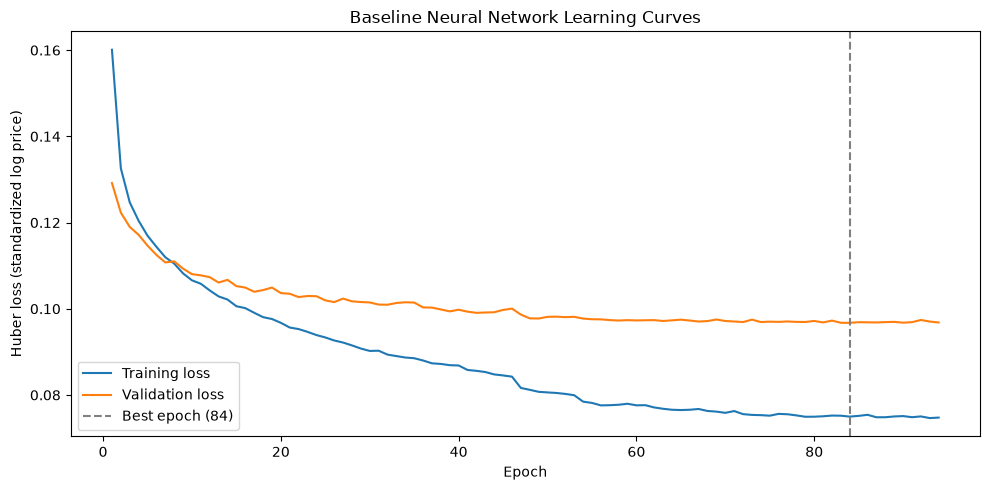

In [16]:
best_epoch = int(baseline_history.loc[baseline_history["valid_loss"].idxmin(), "epoch"])

plt.figure(figsize=(10, 5))

plt.plot(baseline_history["epoch"], baseline_history["train_loss"], label="Training loss")
plt.plot(baseline_history["epoch"], baseline_history["valid_loss"], label="Validation loss")
plt.axvline(best_epoch, linestyle="--", color="grey", label=f"Best epoch ({best_epoch})")

plt.xlabel("Epoch")
plt.ylabel("Huber loss (standardized log price)")
plt.title("Baseline Neural Network Learning Curves")
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation.**

- Both losses fall quickly during the first 10 epochs, which shows that the network learns the main relationships early.
- The training loss keeps decreasing until the end (from 0.160 to approximately 0.075), while the validation loss flattens at approximately 0.097 from about epoch 50 onwards. The reductions of the learning rate in the later epochs give only small further improvements.
- Early stopping selected epoch 84 as the best epoch, and training ended 10 epochs later.
- The gap between the two curves in the second half of training is a sign of **overfitting**: the network continues to fit the training listings more closely without becoming better on unseen listings. The training loss is measured with dropout active, so the real gap is somewhat larger than the curves suggest.

### 4.5 Baseline Performance

The predictions are converted back to dollars and evaluated with the same metrics as the Random Forest:

- **MAE** (mean absolute error): the average size of the error in dollars.
- **RMSE** (root mean squared error): like MAE, but large errors are penalized more heavily.
- **R²**: the proportion of the variance in price that is explained by the model.

The metrics are calculated for the training and validation sets. A large gap between the two would indicate overfitting. The test set is not used.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def predict_prices(model, continuous, categorical,
                   to_dollars=inverse_transform_target, batch_size=4096):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in iterate_batches(len(continuous), batch_size, shuffle=False):
            outputs.append(model(continuous[batch], categorical[batch]))

    outputs = torch.cat(outputs).squeeze(1).cpu().numpy()

    # Convert standardized log prices back to dollars
    return to_dollars(outputs)


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


baseline_train_pred = predict_prices(baseline_model, train_data[0], train_data[1])
baseline_valid_pred = predict_prices(baseline_model, valid_data[0], valid_data[1])

baseline_results = pd.DataFrame({
    "Training": regression_metrics(y_train, baseline_train_pred),
    "Validation": regression_metrics(y_valid, baseline_valid_pred)
}).T

print("Baseline Neural Network Performance:")
display(baseline_results.round(4))

Baseline Neural Network Performance:


,MAE,RMSE,R2
Training,148.2211,261.0657,0.8501
Validation,189.0872,325.0441,0.7621


**Interpretation.**

- On the validation set, the baseline reaches an MAE of approximately \$189, an RMSE of approximately \$325 and an R² of approximately 0.76. On average, a prediction is about \$189 away from the actual rent, and the model explains about 76% of the variance in price.
- The training results are clearly better (MAE of approximately \$148, R² of approximately 0.85). This gap confirms the overfitting seen in the learning curves.
- For reference, the Random Forest achieved an MAE of about \$170 to \$172 and an R² of about 0.776 to 0.779 in 3-fold cross-validation. The two results are not measured on exactly the same listings, but they indicate that the baseline network does not yet match the Random Forest.

The baseline establishes a working reference point. Section 5 tunes the architecture and the regularization to reduce the overfitting and improve the validation performance.

*The exact values can differ slightly between runs, because some GPU operations are not fully deterministic.*

## 5. Hyperparameter Tuning

### 5.1 Tuning Strategy

**Hyperparameters** are settings that are not learned from the data, such as the number of neurons, the dropout rate and the way in which the inputs are represented. They are tuned by training several configurations and comparing them on the validation set.

The baseline showed two weaknesses: it overfits (training MAE of \$148 against a validation MAE of \$189), and it does not yet match the Random Forest. Three directions are examined:

| Direction | Idea | Configurations |
|---|---|---|
| Stronger regularization | A higher dropout rate should reduce overfitting. | `Tuned_1` |
| More capacity | Wider layers can represent more complex relationships. | `Tuned_2` |
| Better input representation | Periodic features for the coordinates (Section 5.2). | `Tuned_3`, `Tuned_4`, `Tuned_5` |

All configurations use the same training procedure as the baseline (Huber loss, AdamW, learning rate schedule and early stopping), so that the differences are caused by the configuration only.

### 5.2 Periodic Features for Latitude and Longitude

**The problem.** Rental prices change sharply over short distances: two neighbourhoods of the same city can have very different price levels. On the standardized scale, however, the coordinates of such neighbourhoods differ only in the second or third decimal place. A neural network with ReLU activations is a smooth function of its inputs and learns slowly varying patterns first (this is known as *spectral bias*). It therefore captures the broad geographic trend, but not the fine local structure. A Random Forest does not have this limitation, because it can place split thresholds at any position along the latitude and longitude.

**The solution.** Each coordinate $x$ is expanded into a set of periodic features:

$$\big[\sin(2\pi f_1 x),\ \cos(2\pi f_1 x),\ \dots,\ \sin(2\pi f_k x),\ \cos(2\pi f_k x)\big]$$

Each frequency $f_j$ produces a wave over the map. Low frequencies change slowly and describe large areas. High frequencies change quickly, so two nearby locations receive clearly different input values. With a mixture of frequencies, the network can represent both the regional price level and the local variation. The frequencies are initialized randomly from a normal distribution with standard deviation $\sigma$ and are then **learned** together with the other weights.

This technique is known as Fourier feature encoding (Tancik et al., 2020) and has been shown to improve neural networks on tabular data (Gorishniy et al., 2022).

$k = 32$ frequencies per coordinate are used, which adds $2 \times 2 \times 32 = 128$ inputs. $\sigma = 30$ is used; preliminary tests showed similar results for values of 10 and above.

In [18]:
class PeriodicFeatures(nn.Module):

    def __init__(self, columns, n_frequencies, sigma):
        super().__init__()

        self.columns = columns

        # One set of learnable frequencies per column
        self.frequencies = nn.Parameter(
            torch.randn(len(columns), n_frequencies) * sigma
        )

    def forward(self, continuous):
        x = continuous[:, self.columns].unsqueeze(-1)
        angles = 2 * torch.pi * self.frequencies * x

        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(1)


class PeriodicRentalPriceNet(RentalPriceNet):

    def __init__(self, category_sizes, n_continuous, periodic_columns,
                 n_frequencies=32, sigma=30.0, **kwargs):

        n_periodic = 2 * len(periodic_columns) * n_frequencies

        # The periodic features are additional continuous inputs
        super().__init__(category_sizes, n_continuous + n_periodic, **kwargs)

        self.periodic = PeriodicFeatures(periodic_columns, n_frequencies, sigma)

    def forward(self, continuous, categorical):
        continuous = torch.cat([continuous, self.periodic(continuous)], dim=1)

        return super().forward(continuous, categorical)


# Positions of latitude and longitude in the continuous input array
coordinate_columns = [
    continuous_features.index(column) for column in coordinate_features
]

print("Coordinate columns:", coordinate_columns)

Coordinate columns: [3, 4]


### 5.3 Candidate Configurations

In [19]:
configurations = [
    {"name": "Baseline", "hidden_sizes": (256, 128, 64), "dropout": 0.1, "periodic": False},
    {"name": "Tuned_1", "hidden_sizes": (256, 128, 64), "dropout": 0.3, "periodic": False},
    {"name": "Tuned_2", "hidden_sizes": (512, 256, 128), "dropout": 0.2, "periodic": False},
    {"name": "Tuned_3", "hidden_sizes": (256, 128, 64), "dropout": 0.1, "periodic": True},
    {"name": "Tuned_4", "hidden_sizes": (512, 256, 128), "dropout": 0.2, "periodic": True},
    {"name": "Tuned_5", "hidden_sizes": (1024, 512, 256), "dropout": 0.3, "periodic": True}
]


def build_model(config, category_sizes=category_sizes):
    # The same seed gives every configuration the same starting conditions
    torch.manual_seed(SEED)

    if config["periodic"]:
        model = PeriodicRentalPriceNet(
            category_sizes=category_sizes,
            n_continuous=len(continuous_features),
            periodic_columns=coordinate_columns,
            hidden_sizes=config["hidden_sizes"],
            dropout=config["dropout"]
        )
    else:
        model = RentalPriceNet(
            category_sizes=category_sizes,
            n_continuous=len(continuous_features),
            hidden_sizes=config["hidden_sizes"],
            dropout=config["dropout"]
        )

    return model.to(device)


display(pd.DataFrame(configurations).set_index("name"))

,hidden_sizes,dropout,periodic
name,,,
Baseline,"(256, 128, 64)",0.1,False
Tuned_1,"(256, 128, 64)",0.3,False
Tuned_2,"(512, 256, 128)",0.2,False
Tuned_3,"(256, 128, 64)",0.1,True
Tuned_4,"(512, 256, 128)",0.2,True
Tuned_5,"(1024, 512, 256)",0.3,True


### 5.4 Hyperparameter Search

Each configuration is trained on the training set with early stopping on the validation set. The baseline from Section 4 is reused and not trained again.

In [20]:
tuned_models = {"Baseline": baseline_model}
tuned_histories = {"Baseline": baseline_history}
tuning_rows = []

for config in configurations:
    name = config["name"]

    if name not in tuned_models:
        model = build_model(config)
        tuned_histories[name] = train_model(model, train_data, valid_data, verbose=False)
        tuned_models[name] = model

    model = tuned_models[name]
    history = tuned_histories[name]

    train_metrics = regression_metrics(
        y_train, predict_prices(model, train_data[0], train_data[1])
    )
    valid_metrics = regression_metrics(
        y_valid, predict_prices(model, valid_data[0], valid_data[1])
    )

    tuning_rows.append({
        "Configuration": name,
        "Parameters": sum(p.numel() for p in model.parameters()),
        "Best epoch": int(history.loc[history["valid_loss"].idxmin(), "epoch"]),
        "Train MAE": train_metrics["MAE"],
        "Valid MAE": valid_metrics["MAE"],
        "Valid RMSE": valid_metrics["RMSE"],
        "Valid R2": valid_metrics["R2"]
    })

    print(f"{name:<9} | valid MAE {valid_metrics['MAE']:.2f} | "
          f"valid RMSE {valid_metrics['RMSE']:.2f} | valid R2 {valid_metrics['R2']:.4f}")

tuning_results = pd.DataFrame(tuning_rows).set_index("Configuration")

Baseline  | valid MAE 189.09 | valid RMSE 325.04 | valid R2 0.7621


Tuned_1   | valid MAE 192.35 | valid RMSE 329.63 | valid R2 0.7553


Tuned_2   | valid MAE 187.48 | valid RMSE 325.90 | valid R2 0.7608


Tuned_3   | valid MAE 160.29 | valid RMSE 285.85 | valid R2 0.8160


Tuned_4   | valid MAE 154.25 | valid RMSE 281.12 | valid R2 0.8221


Tuned_5   | valid MAE 151.62 | valid RMSE 276.39 | valid R2 0.8280


### 5.5 Tuning Results

Hyperparameter tuning results:


,Parameters,Best epoch,Train MAE,Valid MAE,Valid RMSE,Valid R2
Configuration,,,,,,
Baseline,84990,84,148.22,189.09,325.04,0.7621
Tuned_1,84990,94,169.32,192.35,329.63,0.7553
Tuned_2,232318,76,142.49,187.48,325.90,0.7608
Tuned_3,117822,58,105.81,160.29,285.85,0.8160
Tuned_4,297918,67,91.11,154.25,281.12,0.8221
Tuned_5,903870,85,85.70,151.62,276.39,0.8280


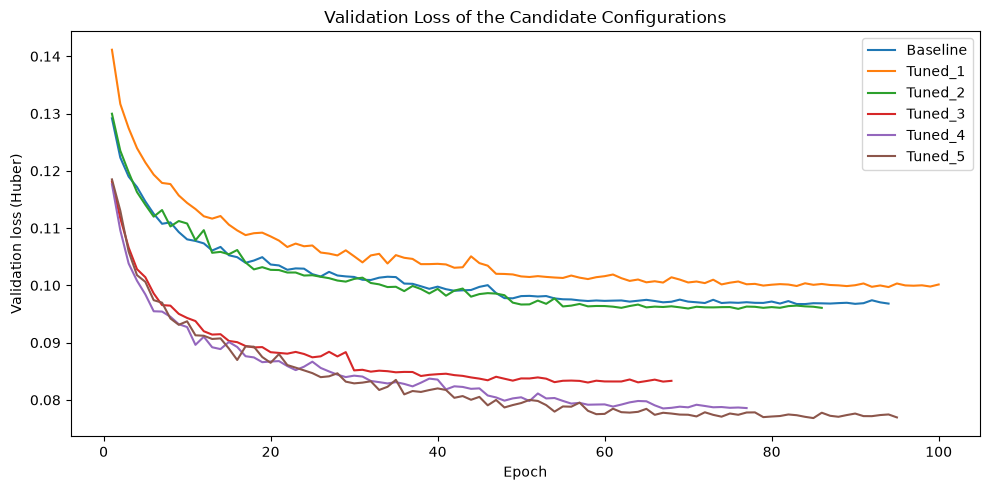

In [21]:
print("Hyperparameter tuning results:")
display(tuning_results.round({
    "Train MAE": 2, "Valid MAE": 2, "Valid RMSE": 2, "Valid R2": 4
}))

# Validation loss of every configuration during training
plt.figure(figsize=(10, 5))

for name, history in tuned_histories.items():
    plt.plot(history["epoch"], history["valid_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation loss (Huber)")
plt.title("Validation Loss of the Candidate Configurations")
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation.**

- **Regularization alone does not help.** `Tuned_1` reduces the gap between training and validation, but its validation MAE (\$192) is worse than the baseline (\$189). The weakness of the baseline was therefore not overfitting alone.
- **Capacity alone does not help.** `Tuned_2` has almost three times as many parameters as the baseline and improves the validation MAE by less than \$2.
- **The input representation makes the difference.** `Tuned_3` has the same layers as the baseline and only adds the periodic features for latitude and longitude. The validation MAE falls from \$189 to \$160 and R² rises from 0.762 to 0.816. This is by far the largest improvement in the study. It confirms that the baseline was limited by its coarse view of location, not by its size.
- **With the periodic features, additional capacity becomes useful.** `Tuned_4` and `Tuned_5` reduce the validation MAE further to \$154 and \$152. The validation loss curves show the same ordering: the three periodic configurations lie clearly below the others throughout training.
- **Training and validation gap.** The periodic configurations fit the training set much more closely than the validation set (for `Tuned_5`, an MAE of \$86 against \$152). The network learns local price levels in great detail, and part of this detail is specific to the training listings. The gap is acceptable because the validation error, which is the criterion for selection, decreased at the same time, and early stopping keeps the weights with the best validation loss.

### 5.6 Selecting the Final Configuration

The configuration with the lowest validation MAE is selected.

In [22]:
best_name = tuning_results["Valid MAE"].idxmin()
best_config = next(c for c in configurations if c["name"] == best_name)

tuned_model = tuned_models[best_name]
tuned_history = tuned_histories[best_name]

print("Selected configuration:", best_config)

comparison = tuning_results.loc[
    ["Baseline", best_name], ["Valid MAE", "Valid RMSE", "Valid R2"]
]

print("\nBaseline vs selected configuration (validation set):")
display(comparison.round(4))

improvement = 1 - comparison.loc[best_name, "Valid MAE"] / comparison.loc["Baseline", "Valid MAE"]
print(f"Reduction in validation MAE: {improvement:.1%}")

Selected configuration: {'name': 'Tuned_5', 'hidden_sizes': (1024, 512, 256), 'dropout': 0.3, 'periodic': True}

Baseline vs selected configuration (validation set):


,Valid MAE,Valid RMSE,Valid R2
Configuration,,,
Baseline,189.0872,325.0441,0.7621
Tuned_5,151.6205,276.3858,0.8280


Reduction in validation MAE: 19.8%


**Interpretation.** `Tuned_5` is selected: three hidden layers with 1,024, 512 and 256 neurons, a dropout rate of 0.3, and periodic features for the coordinates.

| Metric (validation) | Baseline | Tuned_5 |
|---|---|---|
| MAE | \$189.09 | \$151.62 |
| RMSE | \$325.04 | \$276.39 |
| R² | 0.7621 | 0.8280 |

The validation MAE is reduced by 19.8%. The tuned network now also compares favourably with the cross-validation results of the Random Forest (MAE of about \$170 to \$172, R² of about 0.776 to 0.779), although these values are not measured on the same listings.

The validation set was used both for early stopping and for selecting the configuration, so the validation results are slightly optimistic. A comparable estimate is obtained with 3-fold cross-validation in Section 6, and the unbiased estimate is obtained on the test set in Section 7.

## 6. Cross-Validation

### 6.1 Cross-Validation Strategy

The validation results of Section 5 depend on one particular split, and the validation set was used to select the configuration. **K-fold cross-validation** gives a more reliable estimate. The training data is divided into $k$ folds. The model is trained $k$ times, each time on $k-1$ folds, and evaluated on the remaining fold. Every listing is used for evaluation exactly once, and the results are averaged.

The same setting as in the Random Forest notebook is used (3 folds, shuffled, `random_state=42`). The folds are therefore identical, and the cross-validation results of the two models are directly comparable.

Two measures keep each fold free of data leakage:

- **The preprocessing is refitted in every fold.** Medians, clipping limits, scaling parameters, category lists and target statistics are learned from the training part of the fold only. For this purpose the steps of Section 3 are collected in one class.
- **The held-out fold is not used for early stopping.** Within each fold, 15% of the training part is set aside as an inner validation set for early stopping. The held-out fold is used only once, to evaluate the finished model.

In [23]:
class RentalPreprocessor:
    # The preprocessing steps of Section 3, with fit and transform separated

    def fit(self, X, y):
        self.region_medians = X.groupby("region")[coordinate_features].median()
        self.global_medians = X[coordinate_features].median()

        self.clip_bounds = {
            column: (X[column].quantile(lower), X[column].quantile(upper))
            for column, (lower, upper) in clip_quantiles.items()
        }

        self.scaler = StandardScaler()
        self.scaler.fit(self._prepare_numerical(X)[numerical_features])

        self.category_maps = {
            column: {
                category: index
                for index, category in enumerate(sorted(X[column].unique()), start=1)
            }
            for column in categorical_features
        }
        self.category_sizes = {
            column: len(self.category_maps[column]) + 1
            for column in categorical_features
        }

        y_log = np.log1p(y)
        self.target_mean = y_log.mean()
        self.target_std = y_log.std()

        return self

    def _prepare_numerical(self, X):
        X = X.copy()

        # Missing coordinates: indicator and regional median
        X["geo_missing"] = X[coordinate_features].isna().any(axis=1).astype(int)

        for column in coordinate_features:
            X[column] = X[column].fillna(X["region"].map(self.region_medians[column]))
            X[column] = X[column].fillna(self.global_medians[column])

        # Clipping and log transformation
        for column, (lower, upper) in self.clip_bounds.items():
            X[column] = X[column].clip(lower=lower, upper=upper)

        X["sqfeet"] = np.log1p(X["sqfeet"])

        return X

    def transform_features(self, X):
        prepared = self._prepare_numerical(X)
        prepared[numerical_features] = self.scaler.transform(prepared[numerical_features])

        continuous = prepared[continuous_features].to_numpy(dtype="float32")

        categorical = np.column_stack([
            X[column].map(self.category_maps[column]).fillna(UNKNOWN_INDEX).astype("int64")
            for column in categorical_features
        ])

        return continuous, categorical

    def transform_target(self, y):
        y_log = np.log1p(np.asarray(y, dtype="float64"))
        return ((y_log - self.target_mean) / self.target_std).astype("float32")

    def inverse_transform_target(self, y_scaled):
        y_log = np.asarray(y_scaled, dtype="float64") * self.target_std + self.target_mean
        return np.expm1(y_log)


# Check: the class reproduces the arrays of Section 3 exactly
check = RentalPreprocessor().fit(X_train, y_train)
check_cont, check_cat = check.transform_features(X_valid)

print("Continuous inputs identical :", np.array_equal(check_cont, X_valid_cont))
print("Categorical inputs identical:", np.array_equal(check_cat, X_valid_cat))
print("Targets identical           :", np.array_equal(check.transform_target(y_valid), y_valid_scaled))

Continuous inputs identical : True
Categorical inputs identical: True
Targets identical           : True


### 6.2 Cross-Validation of the Selected Configuration

In [24]:
from sklearn.model_selection import KFold

# Same folds as in the Random Forest notebook
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

cv_rows = []

print(f"Starting 3-fold cross-validation of {best_name}...")

for fold, (fold_train_index, held_out_index) in enumerate(kf.split(X_full), start=1):

    X_fold, y_fold = X_full.iloc[fold_train_index], y_full.iloc[fold_train_index]
    X_held_out, y_held_out = X_full.iloc[held_out_index], y_full.iloc[held_out_index]

    # Inner validation set for early stopping
    X_inner_train, X_inner_valid, y_inner_train, y_inner_valid = train_test_split(
        X_fold, y_fold, test_size=0.15, random_state=SEED
    )

    # Preprocessing fitted on the training part of the fold only
    preprocessor = RentalPreprocessor().fit(X_inner_train, y_inner_train)

    fold_train_data = to_tensors(
        *preprocessor.transform_features(X_inner_train),
        preprocessor.transform_target(y_inner_train)
    )
    fold_valid_data = to_tensors(
        *preprocessor.transform_features(X_inner_valid),
        preprocessor.transform_target(y_inner_valid)
    )
    held_out_data = to_tensors(*preprocessor.transform_features(X_held_out))

    # Train the selected configuration
    model = build_model(best_config, preprocessor.category_sizes)
    history = train_model(model, fold_train_data, fold_valid_data, verbose=False)

    # Evaluate on the held-out fold
    held_out_pred = predict_prices(
        model, held_out_data[0], held_out_data[1],
        to_dollars=preprocessor.inverse_transform_target
    )

    metrics = regression_metrics(y_held_out, held_out_pred)
    cv_rows.append({"Fold": fold, "Epochs": len(history), **metrics})

    print(f"\nFold {fold} ({len(X_inner_train):,} training, "
          f"{len(X_held_out):,} held-out listings, {len(history)} epochs)")
    print(f"MAE:  {metrics['MAE']:.2f}")
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"R²:   {metrics['R2']:.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("Fold")

Starting 3-fold cross-validation of Tuned_5...



Fold 1 (81,418 training, 47,893 held-out listings, 71 epochs)
MAE:  163.01
RMSE: 291.50
R²:   0.8101



Fold 2 (81,418 training, 47,893 held-out listings, 78 epochs)
MAE:  162.36
RMSE: 295.72
R²:   0.8072



Fold 3 (81,418 training, 47,893 held-out listings, 50 epochs)
MAE:  164.45
RMSE: 291.79
R²:   0.8142


### 6.3 Cross-Validation Results

The mean cross-validation results are compared with those of the Random Forest, which are taken from `03_RandomForest_Thiwanka.ipynb`.

In [25]:
print("Neural Network cross-validation results:")
display(cv_results.round(4))

print(f"Mean MAE:  {cv_results['MAE'].mean():.2f} (std {cv_results['MAE'].std():.2f})")
print(f"Mean RMSE: {cv_results['RMSE'].mean():.2f} (std {cv_results['RMSE'].std():.2f})")
print(f"Mean R²:   {cv_results['R2'].mean():.4f} (std {cv_results['R2'].std():.4f})")

# Mean 3-fold results reported in 03_RandomForest_Thiwanka.ipynb
cv_comparison = pd.DataFrame({
    "Random Forest (baseline)": {"MAE": 170.22, "RMSE": 318.87, "R2": 0.7756},
    "Random Forest (tuned)": {"MAE": 172.01, "RMSE": 316.11, "R2": 0.7794},
    f"Neural Network ({best_name})": cv_results[["MAE", "RMSE", "R2"]].mean().to_dict()
}).T

print("\nMean 3-fold cross-validation results:")
display(cv_comparison.round(4))

Neural Network cross-validation results:


,Epochs,MAE,RMSE,R2
Fold,,,,
1,71,163.0118,291.5032,0.8101
2,78,162.3556,295.7163,0.8072
3,50,164.4521,291.7881,0.8142


Mean MAE:  163.27 (std 1.07)
Mean RMSE: 293.00 (std 2.35)
Mean R²:   0.8105 (std 0.0036)

Mean 3-fold cross-validation results:


,MAE,RMSE,R2
Random Forest (baseline),170.2200,318.8700,0.7756
Random Forest (tuned),172.0100,316.1100,0.7794
Neural Network (Tuned_5),163.2732,293.0025,0.8105


**Interpretation.**

- **The results are stable across the folds.** The MAE lies between \$162 and \$164 and R² between 0.807 and 0.814. The standard deviation of the MAE is about \$1, so the performance does not depend on a particular split of the data.
- **The Neural Network outperforms the Random Forest on identical folds.** The mean MAE is \$163.27 against \$172.01 for the tuned Random Forest (a reduction of 5.1%), the mean RMSE is \$293.00 against \$316.11 (a reduction of 7.3%), and R² is 0.8105 against 0.7794. The larger gain in RMSE shows that the network makes fewer large errors.
- **The comparison is conservative for the Neural Network.** In each fold, 15% of the training part is set aside for early stopping, so the network learns from 81,418 listings, while the Random Forest uses all 95,786 listings of the training part.
- **The cross-validation error is higher than the validation error of Section 5** (MAE of \$163 against \$152). Two reasons explain this: each fold model is trained on fewer listings (81,418 instead of 122,127), and the validation result of Section 5 was slightly optimistic because the validation set was used to select the configuration. The cross-validation result is the more realistic estimate.

The final evaluation on the held-out test set follows in Section 7.

## 7. Final Evaluation on the Test Set

### 7.1 Test Set Performance

The test set has not been used for training, early stopping or the selection of the configuration. It therefore gives an unbiased estimate of how the model performs on unseen listings. It is evaluated once, with the selected model from Section 5.

In addition to MAE, RMSE and R², the **median absolute error** is reported. It is the error of the typical listing: half of the predictions are closer to the actual price than this value. Unlike the MAE, it is not affected by a small number of very large errors. The mean absolute percentage error (MAPE) is not used, because the listings with a price of \$1 would produce percentage errors of many thousand percent and dominate the average.

The baseline network is evaluated as well, to show the effect of the tuning on unseen data.

In [26]:
from sklearn.metrics import median_absolute_error


def evaluation_metrics(y_true, y_pred):
    return {
        **regression_metrics(y_true, y_pred),
        "Median AE": median_absolute_error(y_true, y_pred)
    }


# Predictions on the test set, in dollars
y_test_pred = predict_prices(tuned_model, test_data[0], test_data[1])
y_test_pred_baseline = predict_prices(baseline_model, test_data[0], test_data[1])

test_results = pd.DataFrame({
    "Neural Network (baseline)": evaluation_metrics(y_test, y_test_pred_baseline),
    f"Neural Network ({best_name})": evaluation_metrics(y_test, y_test_pred)
}).T

print("Final Test Set Evaluation")
display(test_results.round(4))

Final Test Set Evaluation


,MAE,RMSE,R2,Median AE
Neural Network (baseline),188.2173,333.8202,0.7484,105.8255
Neural Network (Tuned_5),149.4815,274.9648,0.8293,79.2868


**Interpretation.**

- **Final performance.** On the test set, the selected network reaches an MAE of \$149.48, an RMSE of \$274.96 and an R² of 0.8293. It explains about 83% of the variance in rental prices.
- **Typical error.** The median absolute error is \$79.29: half of the test listings are predicted within \$79 of the actual price. The MAE is almost twice as high, which shows that the average is raised by a minority of listings with large errors.
- **The model generalizes.** The test results are almost identical to the validation results of Section 5 (MAE of \$151.62, R² of 0.8280). The selection of the configuration on the validation set did therefore not lead to an over-optimistic estimate. The test error is lower than the cross-validation error (\$163), because the final model was trained on more listings than the fold models.
- **Effect of tuning.** Compared with the baseline network, the MAE on unseen data falls from \$188.22 to \$149.48 (a reduction of 20.6%), and R² rises from 0.7484 to 0.8293.

### 7.2 Comparison with the Random Forest

The Random Forest was evaluated on the same test set, so the results are directly comparable. Its results are taken from `03_RandomForest_Thiwanka.ipynb`.

Test set comparison:


,MAE,RMSE,R2
Random Forest (baseline),159.0900,303.6900,0.7918
Random Forest (tuned),161.4000,301.8400,0.7943
Neural Network (baseline),188.2173,333.8202,0.7484
Neural Network (Tuned_5),149.4815,274.9648,0.8293


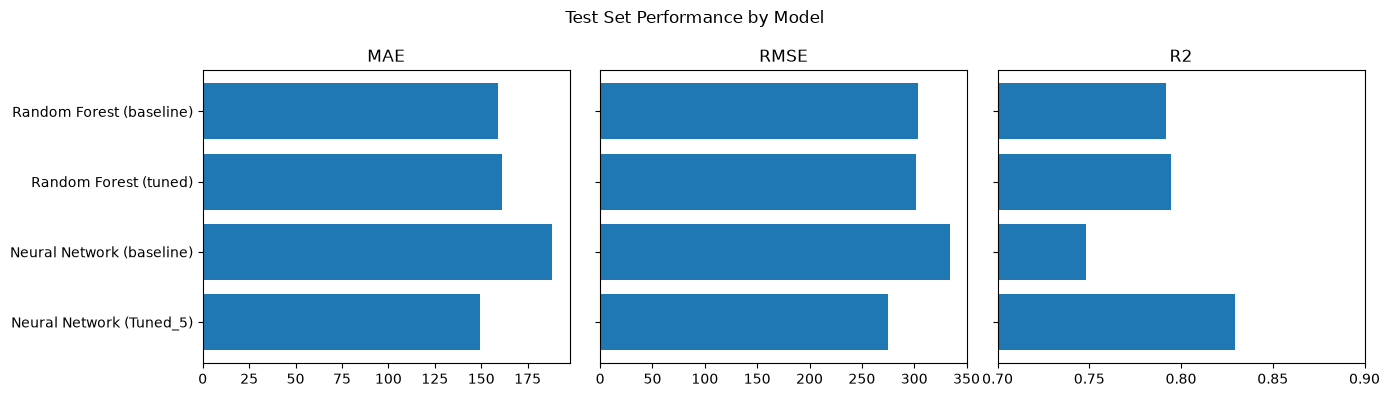

In [27]:
# Test results reported in 03_RandomForest_Thiwanka.ipynb
model_comparison = pd.DataFrame({
    "Random Forest (baseline)": {"MAE": 159.09, "RMSE": 303.69, "R2": 0.7918},
    "Random Forest (tuned)": {"MAE": 161.40, "RMSE": 301.84, "R2": 0.7943},
    "Neural Network (baseline)": test_results.loc["Neural Network (baseline)", ["MAE", "RMSE", "R2"]].to_dict(),
    f"Neural Network ({best_name})": test_results.loc[f"Neural Network ({best_name})", ["MAE", "RMSE", "R2"]].to_dict()
}).T

print("Test set comparison:")
display(model_comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for axis, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    axis.barh(model_comparison.index, model_comparison[metric])
    axis.set_title(metric)
    axis.invert_yaxis()

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])
axes[2].set_xlim(0.7, 0.9)

plt.suptitle("Test Set Performance by Model")
plt.tight_layout()
plt.show()

**Interpretation.**

- **The tuned Neural Network is the best of the four models on every metric.** Compared with the tuned Random Forest, the MAE is \$149.48 against \$161.40 (7.4% lower), the RMSE is \$274.96 against \$301.84 (8.9% lower), and R² is 0.8293 against 0.7943. It also outperforms the baseline Random Forest, which had the lower MAE of the two forests (\$159.09).
- **The baseline Neural Network is the weakest model.** A neural network is therefore not better than a Random Forest by default on this data. The advantage comes from the periodic representation of the coordinates introduced in Section 5, which gives the network the fine geographic resolution that a tree-based model obtains naturally.
- **The result confirms the cross-validation of Section 6**, where the network was also ahead of the Random Forest on all three metrics.

### 7.3 Actual vs Predicted Rental Prices

Each point is one test listing. Points on the dashed line are perfect predictions. Points below the line are listings whose price is underestimated, and points above it are overestimated.

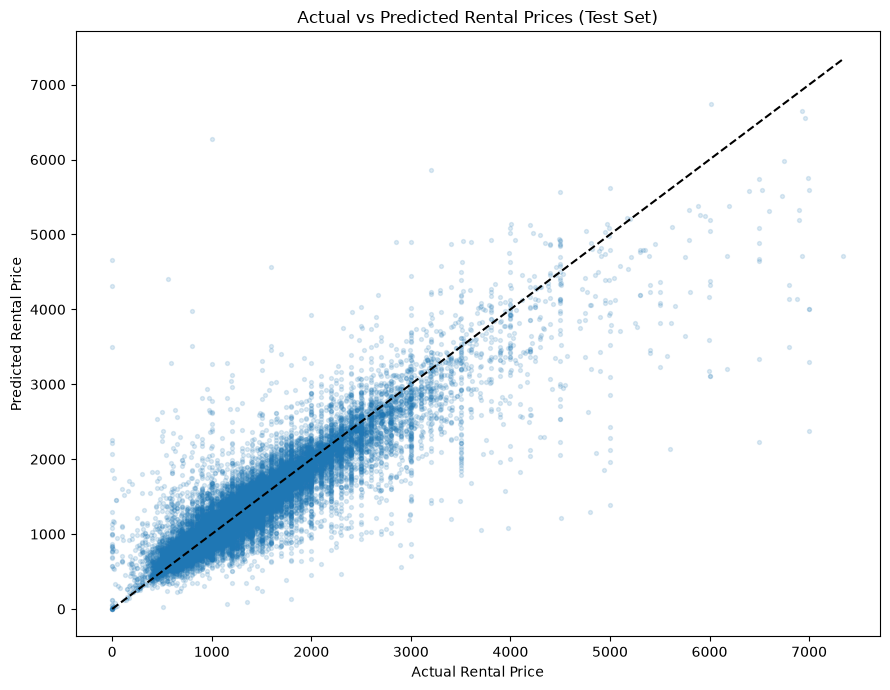

In [28]:
plt.figure(figsize=(9, 7))

plt.scatter(y_test, y_test_pred, alpha=0.15, s=8)

max_price = max(y_test.max(), y_test_pred.max())
plt.plot([0, max_price], [0, max_price], linestyle="--", color="black")

plt.xlabel("Actual Rental Price")
plt.ylabel("Predicted Rental Price")
plt.title("Actual vs Predicted Rental Prices (Test Set)")

plt.tight_layout()
plt.show()

### 7.4 Residual Analysis

A residual is the difference between the actual and the predicted price. A positive residual means that the model predicted too low, and a negative residual that it predicted too high. For a good model, the residuals are centred on zero, roughly symmetric, and show no pattern when plotted against the predicted price.

Residual Summary
-----------------------------------
Mean residual   : 14.32
Median residual : 2.60
Minimum residual: -5280.51
Maximum residual: 4619.29
Within $100     : 57.9% of listings
Within $200     : 78.9% of listings


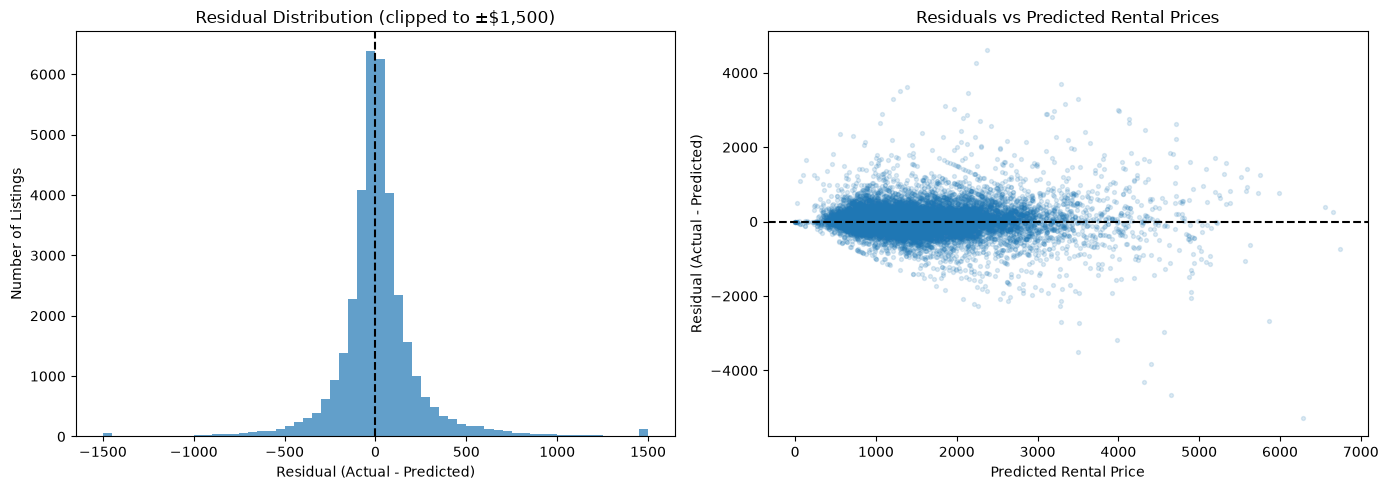

In [29]:
residuals = y_test - y_test_pred

print("Residual Summary")
print("-" * 35)
print(f"Mean residual   : {residuals.mean():.2f}")
print(f"Median residual : {residuals.median():.2f}")
print(f"Minimum residual: {residuals.min():.2f}")
print(f"Maximum residual: {residuals.max():.2f}")
print(f"Within $100     : {(residuals.abs() <= 100).mean():.1%} of listings")
print(f"Within $200     : {(residuals.abs() <= 200).mean():.1%} of listings")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals.clip(-1500, 1500), bins=60, alpha=0.7)
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_xlabel("Residual (Actual - Predicted)")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title("Residual Distribution (clipped to ±$1,500)")

axes[1].scatter(y_test_pred, residuals, alpha=0.15, s=8)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("Predicted Rental Price")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residuals vs Predicted Rental Prices")

plt.tight_layout()
plt.show()

**Interpretation.**

- **The predictions are almost unbiased.** The mean residual is \$14.32 and the median residual is \$2.60. On average, prices are underestimated very slightly.
- **Most errors are small.** 57.9% of the test listings are predicted within \$100 of the actual price and 78.9% within \$200. The histogram is narrow, centred on zero and roughly symmetric.
- **The spread grows with the price.** In the plot of residuals against predicted prices, the points are centred on zero over the whole range, so there is no systematic pattern. The spread widens for higher predicted prices. This is expected, because the model is trained on the log scale and therefore keeps the *relative* error constant: a 10% error is larger in dollars for an expensive listing.
- **The largest errors are caused by implausible listings.** The actual-versus-predicted plot shows a column of points at an actual price close to \$0, for which the model predicts ordinary rents of several hundred to several thousand dollars. These are the erroneous \$1 listings identified in Section 3.7. The predictions for them are reasonable, but they are counted as large errors and raise the RMSE in particular.
- **Vertical stripes** appear at round prices such as \$3,000, \$3,500 and \$4,000, because landlords prefer round amounts. The model predicts a continuous range of values for these listings.

### 7.5 Error by Price Range

The overall metrics hide how the error varies across the price range. The test listings are grouped by their actual price. For each group, the MAE and the mean residual are calculated. The mean residual shows the direction of the error: a positive value means that the prices in that group are underestimated on average.

In [30]:
price_bands = pd.cut(
    y_test,
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=["Up to $500", "$500-$1,000", "$1,000-$1,500",
            "$1,500-$2,000", "$2,000-$3,000", "Above $3,000"]
)

error_by_band = (
    pd.DataFrame({
        "band": price_bands,
        "absolute_error": residuals.abs(),
        "residual": residuals,
        "price": y_test
    })
    .groupby("band", observed=True)
    .agg(
        Listings=("price", "size"),
        MAE=("absolute_error", "mean"),
        Mean_residual=("residual", "mean"),
        Mean_price=("price", "mean")
    )
)

error_by_band["Share (%)"] = error_by_band["Listings"] / len(y_test) * 100
error_by_band["MAE / mean price (%)"] = error_by_band["MAE"] / error_by_band["Mean_price"] * 100

print("Test error by actual price range:")
display(error_by_band[
    ["Listings", "Share (%)", "MAE", "Mean_residual", "MAE / mean price (%)"]
].round(1))

Test error by actual price range:


,Listings,Share (%),MAE,Mean_residual,MAE / mean price (%)
band,,,,,
Up to $500,767,2.1,274.6,-267.4,70.9
"$500-$1,000",13334,37.1,95.4,-42.5,11.8
"$1,000-$1,500",12432,34.6,122.2,8.9,9.8
"$1,500-$2,000",5593,15.6,166.2,43.9,9.6
"$2,000-$3,000",2940,8.2,294.8,166.5,12.2
"Above $3,000",854,2.4,668.8,516.5,17.1


**Interpretation.**

- **The model is most accurate where most of the data lies.** For listings between \$500 and \$2,000, which make up 87% of the test set, the MAE is between \$95 and \$166, and the error is about 10% to 12% of the average price in each group.
- **Cheap listings are overestimated.** In the group up to \$500, the mean residual is −\$267. This small group (2.1% of the listings) contains the implausible \$1 listings, which explains most of its high error.
- **Expensive listings are underestimated.** Above \$3,000, the mean residual is +\$517 and the MAE is \$669. Only 2.4% of the listings fall in this group.
- **The pattern is a regression towards the mean:** predictions for both ends of the price range are pulled towards typical prices. Two reasons contribute. There are few listings at the extremes to learn from, and the available features do not describe what makes a property unusually cheap or expensive, such as its condition, interior quality or view.

### 7.6 Feature Importance

A neural network has no built-in measure of feature importance. **Permutation importance** is used instead. The values of one feature are shuffled across the listings, which breaks the relationship between that feature and the price while keeping its distribution. The increase in MAE that follows shows how much the model relies on the feature. A feature whose shuffling does not change the error is not used by the model.

The importance is calculated on the validation set, with three repetitions per feature.

Permutation importance (increase in validation MAE, in dollars):


,Feature,MAE increase
0,long,168.53
1,region,129.61
2,sqfeet,97.72
3,lat,86.98
4,state,52.64
5,laundry_options,41.96
6,type,29.20
7,parking_options,25.73
8,beds,24.85
9,baths,14.94


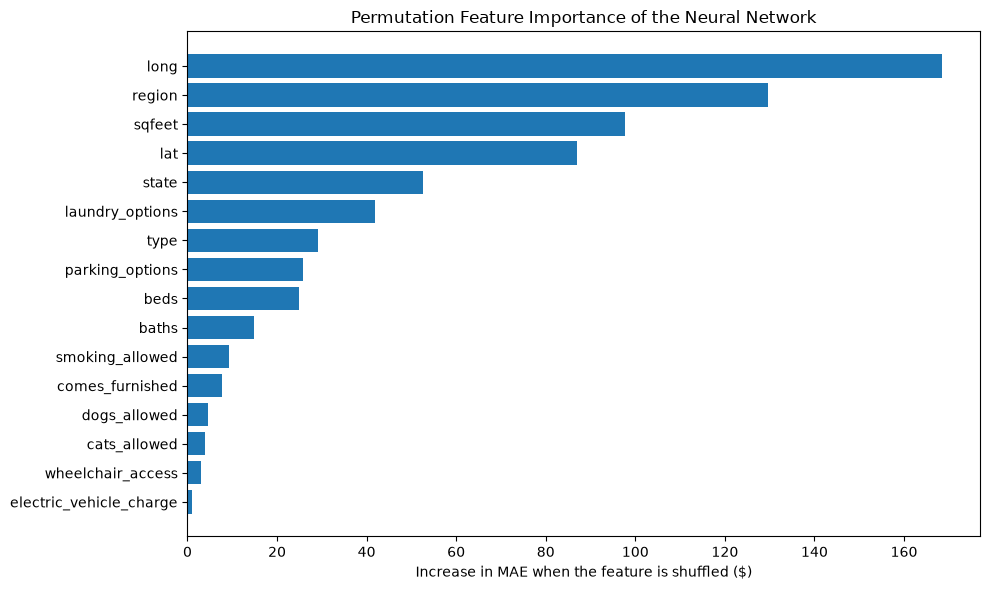

In [31]:
def permutation_importance(model, X, y, n_repeats=3):
    rng = np.random.default_rng(SEED)

    def model_mae(features):
        continuous, categorical = to_tensors(*preprocess_features(features))
        return mean_absolute_error(y, predict_prices(model, continuous, categorical))

    reference_mae = model_mae(X)
    rows = []

    for column in X.columns:
        increases = []

        for _ in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[column] = rng.permutation(X_permuted[column].to_numpy())
            increases.append(model_mae(X_permuted) - reference_mae)

        rows.append({"Feature": column, "MAE increase": np.mean(increases)})

    return pd.DataFrame(rows).sort_values("MAE increase", ascending=False)


feature_importance = permutation_importance(tuned_model, X_valid, y_valid)

print("Permutation importance (increase in validation MAE, in dollars):")
display(feature_importance.round(2).reset_index(drop=True))

plot_data = feature_importance.sort_values("MAE increase")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Feature"], plot_data["MAE increase"])
plt.xlabel("Increase in MAE when the feature is shuffled ($)")
plt.title("Permutation Feature Importance of the Neural Network")

plt.tight_layout()
plt.show()

**Interpretation.**

- **Location dominates.** Four of the five most important features describe where the property is: `long` (+\$169), `region` (+\$130), `lat` (+\$87) and `state` (+\$53). This agrees with the finding of Section 5 that the representation of location determines the performance of the network.
- **Size is the most important property characteristic.** Shuffling `sqfeet` increases the MAE by \$98. `beds` (+\$25) and `baths` (+\$15) add less, because much of their information is already contained in the size.
- **Amenities matter moderately.** `laundry_options` (+\$42), `type` (+\$29) and `parking_options` (+\$26) contribute, while the six binary features change the error by less than \$10 each.
- **Agreement with the Random Forest.** Its most important features were the encoded region, the square footage, the longitude and the latitude. Both models rely on the same information.

The location features are strongly related to each other: a region determines the state and the approximate coordinates. Shuffling one of them creates combinations that do not exist, such as coordinates that do not match the region. The individual values of these features should therefore be read as an indication of their importance, not as an exact measurement.

### 7.7 Summary of the Final Model

| Item | Value |
|---|---|
| Model | Feed-forward neural network with embeddings and periodic coordinate features (`Tuned_5`) |
| Hidden layers | 1,024, 512 and 256 neurons, batch normalization, ReLU, dropout 0.3 |
| Test MAE | \$149.48 |
| Test RMSE | \$274.96 |
| Test R² | 0.8293 |
| Test median absolute error | \$79.29 |
| 3-fold cross-validation MAE | \$163.27 |

The tuned Neural Network outperforms the Random Forest in cross-validation and on the test set. Its predictions are almost unbiased and most accurate in the price range that contains the majority of the listings. Its main limitations are the larger errors at the extremes of the price range and its dependence on the location features. Possible further improvements are described in `models/neural_network/IMPROVEMENTS.md`.

## 8. Saving the Final Model

A trained network exists only in memory. To use it outside this notebook, it must be saved to a file. The weights alone are not sufficient: they are only valid together with the exact preprocessing values they were trained with. A listing must be imputed, clipped, standardized and encoded with the same medians, limits, means, standard deviations and category indices as the training data, and the output must be converted back to dollars with the same target statistics.

The final model is therefore packaged in `models/neural_network/`, following the structure of the Random Forest package:

| File | Contents |
|---|---|
| `neural_network.py` | The preprocessing, the network and the training procedure of this notebook, and a prediction interface |
| `train_model.py` | A script that trains the selected configuration on `raw_train.csv` and saves it |
| `artifacts/neural_network.pt` | The saved model: network weights, fitted preprocessing values and configuration |

The model is trained and saved with the following command, run from the project folder:

```
python -m models.neural_network.train_model --evaluate-test
```

The script uses the same configuration, data split and random seed as this notebook. The cell below loads the saved model and verifies it on the test set.

In [32]:
import sys

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# The models package is located in the project folder
sys.path.append("..")

from models.neural_network import NeuralNetworkRentalPriceModel

saved_model = NeuralNetworkRentalPriceModel.load()

# The saved model takes raw listings and returns prices in dollars
saved_test_pred = saved_model.predict(X_test)

print("Saved model on the test set")
print(f"MAE:  {mean_absolute_error(y_test, saved_test_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, saved_test_pred)):.2f}")
print(f"R²:   {r2_score(y_test, saved_test_pred):.4f}")

# Prediction for a single listing
example = X_test.iloc[0]

print("\nExample listing:")
print(example.to_string())
print(f"\nPredicted price: ${saved_model.predict_one(example):,.2f}")
print(f"Actual price   : ${y_test.iloc[0]:,.2f}")

Saved model on the test set
MAE:  149.48
RMSE: 274.96
R²:   0.8293

Example listing:
region                     phoenix
type                         condo
sqfeet                        1700
beds                             3
baths                          2.5
cats_allowed                     1
dogs_allowed                     1
smoking_allowed                  0
wheelchair_access                0
electric_vehicle_charge          0
comes_furnished                  1
laundry_options            Unknown
parking_options            carport
lat                        33.5576
long                      -112.131
state                           az

Predicted price: $1,398.18
Actual price   : $1,275.00


**Interpretation.** The saved model reproduces the test results of Section 7 exactly (MAE of \$149.48, RMSE of \$274.96, R² of 0.8293). This confirms that the saved file contains everything that is needed for prediction, and that the packaged code is equivalent to this notebook. For the example listing, the model predicts \$1,398.18 against an actual price of \$1,275.